# Configuración inicial: descargas e importaciones necesarias

In [ ]:
!pip install -q seqeval tf2crf "keras<3.0" tensorflow tensorflow-addons
!pip install -q spacy==3.7.2 thinc==8.2.2
!pip install -q gensim

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/Personal/Universidad/8° Semestre/PLN/Taller 2/custom_utils')

In [ ]:
from mwrapper import ModelWithCRFLoss

/usr/local/lib/python3.11/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [ ]:
import logging
import os
import pickle
import re
import time
from collections import Counter
from itertools import chain
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union


import matplotlib.pyplot as plt
import numpy as np
import requests
import spacy
import tensorflow as tf
from gensim.models import Word2Vec
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
from spacy import displacy
from spacy.tokens import Doc, Span
from tensorflow.keras.layers import (
    LSTM,
    Bidirectional,
    Embedding,
    Input,
    Masking,
    SpatialDropout1D,
)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow_addons.layers import CRF

In [ ]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 89.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')


In [ ]:
# Crea un logger asociado al nombre del módulo actual
logger = logging.getLogger(__name__)

# Configura el nivel de log global a INFO (muestra mensajes informativos en consola)
logging.basicConfig(level=logging.INFO)

# Configuración de rutas y estructura de carpetas

In [ ]:
# Define la ruta base del proyecto en Google Drive
BASE_DIR = Path("/content/drive/MyDrive/Personal/Universidad/8° Semestre/PLN/Taller 2")

# Define subdirectorios para datos y embeddings
DATA_DIR = BASE_DIR / "data"
EMB_DIR = BASE_DIR / "embeddings"

# Crea los directorios si no existen (incluye carpetas padre)
for d in (DATA_DIR, EMB_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Define las rutas a los archivos de datos (crudos y limpiados)
TRAIN_FILE = DATA_DIR / "training.bio"
DEV_FILE = DATA_DIR / "validation.bio"
TEST_FILE = DATA_DIR / "testing.bio"
DEV_FILE_CLEANED = DATA_DIR / "validation_cleaned.bio"
TEST_FILE_CLEANED = DATA_DIR / "testing_cleaned.bio"

print("Archivos configurados:")
print("  train         ->", TRAIN_FILE)
print("  dev           ->", DEV_FILE)
print("  test          ->", TEST_FILE)
print("  dev_cleaned   ->", DEV_FILE_CLEANED)
print("  test_cleaned  ->", TEST_FILE_CLEANED)

Archivos configurados:
  train         -> /content/drive/MyDrive/Personal/Universidad/8° Semestre/PLN/Taller 2/data/training.bio
  dev           -> /content/drive/MyDrive/Personal/Universidad/8° Semestre/PLN/Taller 2/data/validation.bio
  test          -> /content/drive/MyDrive/Personal/Universidad/8° Semestre/PLN/Taller 2/data/testing.bio
  dev_cleaned   -> /content/drive/MyDrive/Personal/Universidad/8° Semestre/PLN/Taller 2/data/validation_cleaned.bio
  test_cleaned  -> /content/drive/MyDrive/Personal/Universidad/8° Semestre/PLN/Taller 2/data/testing_cleaned.bio


# Carga y procesamiento del corpus en formato BIO

In [ ]:
# Carga un corpus en formato BIO desde un archivo y devuelve oraciones, etiquetas y líneas mal formateadas
def load_bio_corpus(path, verbose=True):
    # Inicializa listas para oraciones, etiquetas y líneas inválidas
    sents, labels, bad_lines = [], [], []
    tokens, tags = [], []

    # Abre el archivo con codificación UTF-8
    with open(path, encoding="utf-8") as f:
        # Recorre línea por línea, con número de línea para facilitar diagnóstico
        for lineno, raw in enumerate(f, 1):
            # Elimina espacios en blanco al inicio/final
            line = raw.strip()

            # Si la línea está vacía, guarda la oración actual y reinicia buffers
            if not line:
                if tokens:
                    sents.append(tokens)
                    labels.append(tags)
                    tokens, tags = [], []
                continue

            # Ignora encabezados o marcadores de documento
            if line.startswith(("#", "-DOCSTART-")):
                continue

            # Divide la línea por espacios
            parts = line.split()

            # Si no hay al menos token y etiqueta, se marca como línea mal formateada
            if len(parts) < 2:
                bad_lines.append((lineno, raw))
                continue

            # Extrae el token y la etiqueta (último elemento)
            token, tag = parts[0], parts[-1]
            tokens.append(token)
            tags.append(tag)

    # Añade la última oración si quedó algo pendiente
    if tokens:
        sents.append(tokens)
        labels.append(tags)

    # Muestra advertencia si hay líneas mal formateadas y verbose está activado
    if verbose and bad_lines:
        logger.warning(f"{len(bad_lines)} líneas ignoradas por formato incorrecto.")

    # Retorna las oraciones, etiquetas y líneas problemáticas
    return sents, labels, bad_lines

In [ ]:
# Carga las oraciones y etiquetas del conjunto de entrenamiento desde el archivo BIO
train_tokens, train_labels, _ = load_bio_corpus(TRAIN_FILE)

# Carga las oraciones y etiquetas del conjunto de validación
valid_tokens, valid_labels, _ = load_bio_corpus(DEV_FILE)

# Carga las oraciones y etiquetas del conjunto de prueba
test_tokens, test_labels, _ = load_bio_corpus(TEST_FILE)

print(f"Train: {len(train_tokens)} oraciones")
print(f"Valid: {len(valid_tokens)} oraciones")
print(f"Test:  {len(test_tokens)} oraciones")

for sent, labels in zip(train_tokens[:2], train_labels[:2]):
    print(list(zip(sent, labels)))

Train: 3106 oraciones
Valid: 929 oraciones
Test:  991 oraciones
[('Paciente', 'O'), ('de', 'O'), ('72', 'B-EDAD'), ('años', 'I-EDAD'), (',', 'O'), ('con', 'O'), ('antecedentes', 'O'), ('médicos', 'O'), ('de', 'O'), ('HTA', 'O'), ('.', 'O')]
[('Actualmente', 'O'), ('con', 'O'), ('tumor', 'O'), ('de', 'O'), ('próstata', 'O'), ('BILATERAL', 'O'), (',', 'O'), ('con', 'O'), ('biopsia', 'O'), ('de', 'O'), ('adenocarcinoma', 'B-CANCER'), ('GLEASON', 'B-GLEASON'), ('SCORE', 'I-GLEASON'), ('3+3', 'I-GLEASON'), (',', 'O'), ('PSA', 'B-BIOMARCADOR'), ('mas', 'I-BIOMARCADOR'), ('alto', 'I-BIOMARCADOR'), ('reportado', 'I-BIOMARCADOR'), ('en', 'I-BIOMARCADOR'), ('HC', 'I-BIOMARCADOR'), ('9,9', 'I-BIOMARCADOR'), ('ng/dl', 'I-BIOMARCADOR'), ('PSA', 'B-BIOMARCADOR'), ('en', 'I-BIOMARCADOR'), ('9,9', 'I-BIOMARCADOR'), ('ng/dl', 'I-BIOMARCADOR'), ('PSA', 'B-BIOMARCADOR'), ('PSA', 'B-BIOMARCADOR'), ('7,57', 'I-BIOMARCADOR'), ('ng/mL', 'I-BIOMARCADOR'), ('PSA', 'B-BIOMARCADOR'), ('en', 'I-BIOMARCADOR'), ('9

In [ ]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
PAD_IDX = 0
UNK_IDX = 1

In [ ]:
# Construye un vocabulario a partir de una lista de oraciones (listas de tokens)
# Incluye tokens especiales para padding y palabras desconocidas
def build_vocab(sentences, pad_token=PAD_TOKEN, unk_token=UNK_TOKEN):
    word2idx = {pad_token: PAD_IDX, unk_token: UNK_IDX}
    for word in Counter(chain.from_iterable(sentences)):
        word2idx.setdefault(word, len(word2idx))
    return word2idx

# Construye un diccionario de etiquetas con su índice a partir de una lista de secuencias de etiquetas
def build_label_map(labels):
    label_set = sorted(set(chain.from_iterable(labels)))
    return {label: idx for idx, label in enumerate(label_set)}

# Codifica una oración como una secuencia de índices según el vocabulario
def encode_sentence(tokens, word2idx):
    return [word2idx.get(token, word2idx[UNK_TOKEN]) for token in tokens]

# Codifica una lista de oraciones usando un vocabulario
def encode_sentences(sentences, word2idx):
    return [encode_sentence(sent, word2idx) for sent in sentences]

# Codifica secuencias de etiquetas usando el mapeo de etiquetas a índices
# Si una etiqueta no existe, asigna el índice de "O" por defecto
def encode_tags(tags, tag2idx):
    return [[tag2idx.get(tag, tag2idx["O"]) for tag in tag_seq] for tag_seq in tags]

# Invierte el vocabulario para obtener un mapeo de índices a palabras
def get_idx2word(word2idx):
    return {i: w for w, i in word2idx.items()}

# Invierte el diccionario de etiquetas para obtener un mapeo de índices a etiquetas
def get_idx2tag(tag2idx):
    return {i: t for t, i in tag2idx.items()}

# Tokeniza un texto en palabras, separando por caracteres no alfanuméricos pero conservándolos
def tokenize_text(text):
    return [t for t in re.split(r"(\W)", text) if t.strip()]

In [ ]:
# Aplica padding a una lista de secuencias para que todas tengan la misma longitud
# Utiliza la función pad_sequences de Keras con configuración flexible
def pad_sequences_tf(
    sequences,
    maxlen,
    pad_value=PAD_IDX,
    padding="post",
    truncating="post",
):
    return pad_sequences(
        sequences,
        maxlen=maxlen,
        value=pad_value,
        padding=padding,
        truncating=truncating,
    )

In [ ]:
# Preprocesa un único texto: tokeniza, codifica y aplica padding para usar como entrada al modelo
def preprocess_single_text(
    text,
    word2idx,
    max_len,
):
    # Tokeniza el texto en palabras y signos de puntuación
    tokens = tokenize_text(text)

    # Codifica los tokens en índices usando el vocabulario
    encoded = encode_sentence(tokens, word2idx)

    # Aplica padding a la secuencia codificada para ajustarla a la longitud máxima
    padded = pad_sequences_tf([encoded], maxlen=max_len)

    # Retorna la secuencia ya procesada (como array plano)
    return padded[0]

In [ ]:
# Construye el vocabulario a partir de los tokens de entrenamiento
word2idx = build_vocab(train_tokens)

# Construye el mapeo de etiquetas (BIO) a índices
tag2idx = build_label_map(train_labels)

# Muestra el diccionario de etiquetas para verificar su contenido
print(tag2idx)

# Crea los mapeos inversos de índices a palabras y etiquetas
idx2tag = get_idx2tag(tag2idx)
idx2word = get_idx2word(word2idx)

# Codifica las oraciones de cada partición usando el vocabulario
X_train = encode_sentences(train_tokens, word2idx)
X_valid = encode_sentences(valid_tokens, word2idx)
X_test  = encode_sentences(test_tokens, word2idx)

# Codifica las secuencias de etiquetas para cada partición
y_train = encode_tags(train_labels, tag2idx)
y_valid = encode_tags(valid_labels, tag2idx)
y_test  = encode_tags(test_labels, tag2idx)

# Define la longitud máxima de secuencia como el percentil 98 del set de entrenamiento
MAX_LEN = int(np.percentile([len(seq) for seq in X_train], 98))

# Aplica padding a las secuencias codificadas de entrada
X_train = pad_sequences_tf(X_train, maxlen=MAX_LEN)
X_valid = pad_sequences_tf(X_valid, maxlen=MAX_LEN)
X_test  = pad_sequences_tf(X_test, maxlen=MAX_LEN)

# Aplica padding a las secuencias de etiquetas
y_train = pad_sequences_tf(y_train, maxlen=MAX_LEN)
y_valid = pad_sequences_tf(y_valid, maxlen=MAX_LEN)
y_test  = pad_sequences_tf(y_test, maxlen=MAX_LEN)

print(f"MAX_LEN elegido (percentil 98): {MAX_LEN}")
print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de y_train: {y_train.shape}")

sample_idx = 0
print("\n🔎 Ejemplo de oración codificada (X_train):")
print(X_train[sample_idx])
print("\n🔁 Decodificada:")
print([idx2word.get(idx, "<UNK>") for idx in X_train[sample_idx]])

print("\n🔎 Etiquetas codificadas (y_train):")
print(y_train[sample_idx])
print("\n🔁 Decodificadas:")
print([idx2tag.get(idx, "O") for idx in y_train[sample_idx] if idx != PAD_IDX])

{'B-BIOMARCADOR': 0, 'B-CANCER': 1, 'B-CIRUGIA': 2, 'B-DOSIS': 3, 'B-EDAD': 4, 'B-FECHA': 5, 'B-GLEASON': 6, 'B-MEDICAMENTO': 7, 'B-TNM': 8, 'B-TRATAMIENTO': 9, 'I-BIOMARCADOR': 10, 'I-CANCER': 11, 'I-CIRUGIA': 12, 'I-DOSIS': 13, 'I-EDAD': 14, 'I-FECHA': 15, 'I-GLEASON': 16, 'I-MEDICAMENTO': 17, 'I-TNM': 18, 'I-TRATAMIENTO': 19, 'O': 20}
MAX_LEN elegido (percentil 98): 78
Shape de X_train: (3106, 78)
Shape de y_train: (3106, 78)

🔎 Ejemplo de oración codificada (X_train):
[ 2  3  4  5  6  7  8  9  3 10 11  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0]

🔁 Decodificada:
['Paciente', 'de', '72', 'años', ',', 'con', 'antecedentes', 'médicos', 'de', 'HTA', '.', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>

# Descarga de corpus

In [ ]:
# Preprocesa textos en español desde una carpeta para entrenar Word2Vec
# Devuelve una lista de listas de tokens (una por oración o documento)
def preprocess_texts_for_word2vec(
    folder_path=BASE_DIR / "CodiEsp",
    sentenize=True,
):

    # Carga el modelo de spaCy en español, desactivando procesamiento innecesario
    nlp = spacy.load("es_core_news_sm", disable=["ner", "parser", "tagger"])

    # Añade el componente sentencizer para dividir en oraciones
    nlp.add_pipe("sentencizer")

    # Lista para almacenar las unidades procesadas (tokens por oración o por documento)
    corpus = []

    # Recorre los archivos .txt en la carpeta indicada
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            file_path = os.path.join(folder_path, filename)

            # Lee el contenido del archivo
            with open(file_path, "r", encoding="utf-8") as f:
                text = f.read().strip()

            # Procesa el texto con spaCy
            doc = nlp(text)

            # Si se activa sentenize, se tokeniza por oración
            if sentenize:
                for sent in doc.sents:
                    tokens = [
                        token.text.lower()
                        for token in sent
                        if not token.is_punct and not token.is_space
                    ]
                    if tokens:
                        corpus.append(tokens)
            else:
                # Si no se usa sentenize, se tokeniza todo el documento como una unidad
                tokens = [
                    token.text.lower()
                    for token in doc
                    if not token.is_punct and not token.is_space
                ]
                if tokens:
                    corpus.append(tokens)

    # Registra la cantidad de unidades procesadas en el log
    logger.info(
        f"✅ Se procesaron {len(corpus)} unidades (oraciones o documentos) desde '{folder_path}'."
    )

    # Devuelve el corpus listo para entrenamiento de embeddings
    return corpus

In [ ]:
# Procesa los textos del corpus en oraciones tokenizadas para entrenamiento de Word2Vec
sentences = preprocess_texts_for_word2vec(sentenize=True)

In [ ]:
print(f"Cantidad de oraciones en el corpus: {len(sentences)}")
print("\nEjemplo de una oración:")
print(sentences[0])
print("Cantidad de tokens")
sum = 0
for sent in sentences:
  sum += len(sent)
print(sum)

Cantidad de oraciones en el corpus: 12450

Ejemplo de una oración:
['varón', 'de', '32', 'años', 'de', 'edad', 'acude', 'a', 'urgencias', 'del', 'hospital', 'en', 'febrero', 'de', '2000', 'por', 'presentar', 'dolor', 'en', 'hombro', 'izquierdo', 'y', 'columna', 'lumbar']
Cantidad de tokens
279788


In [ ]:
EMB_DIM = 300

In [ ]:
# Entrena un modelo Word2Vec usando las oraciones tokenizadas
# vector_size define la dimensión del embedding, window el contexto, workers los hilos de procesamiento
model = Word2Vec(sentences, vector_size=EMB_DIM, window=5, workers=4)

In [ ]:
print("Tamaño del vocabulario:", len(model.wv.key_to_index))
print("Tamaño del embedding:", model.vector_size)

Tamaño del vocabulario: 5353
Tamaño del embedding: 300


In [ ]:
# Define la ruta donde se guardarán los embeddings entrenados
drive_path = BASE_DIR / "embeddings"

# Crea el directorio si no existe
os.makedirs(drive_path, exist_ok=True)

# Guarda el modelo Word2Vec completo en formato nativo de Gensim
model.save(os.path.join(drive_path, "word2vec_prostata.model"))

# Exporta los vectores en formato Word2Vec (texto plano, compatible con otros frameworks)
model.wv.save_word2vec_format(
    os.path.join(drive_path, "word2vec_prostata.vec"),
    binary=False
)

In [ ]:
# Construye una matriz de embeddings a partir de un vocabulario y un modelo Word2Vec entrenado
def build_embedding_matrix(word2idx, w2v_model, emb_dim=EMB_DIM):

    # Calcula el tamaño del vocabulario
    vocab_size = len(word2idx)

    # Inicializa la matriz de embeddings con ceros (shape: vocab_size x dimensión de embeddings)
    embedding_matrix = np.zeros((vocab_size, emb_dim))

    # Recorre cada palabra e índice en el vocabulario
    for word, idx in word2idx.items():
        # Si la palabra existe en el modelo Word2Vec, asigna su vector a la posición correspondiente
        if word in w2v_model.wv:
            embedding_matrix[idx] = w2v_model.wv[word]

    # Registra en el log la forma final de la matriz construida
    logger.info(f"✅ Embedding matrix construida: shape {embedding_matrix.shape}")

    # Devuelve la matriz lista para usar como pesos iniciales en una capa de embedding
    return embedding_matrix

In [ ]:
# Carga el modelo Word2Vec desde disco y construye la matriz de embeddings a partir del vocabulario
embedding_matrix = build_embedding_matrix(
    word2idx,
    Word2Vec.load(os.path.join(BASE_DIR / "embeddings", "word2vec_prostata.model"))
)

# Construcción, guardado y carga del modelo BiLSTM + CRF

In [ ]:
# Define constantes por defecto para los hiperparámetros del modelo
DEFAULT_LSTM_UNITS = 128
DEFAULT_DROPOUT = 0.25
DEFAULT_TRAINABLE_EMB = True
DEFAULT_USE_MASKING = True

# Construye y devuelve un modelo BiLSTM-CRF para tareas de etiquetado de secuencias
def build_bilstm_crf_model(
    max_len=MAX_LEN,
    n_words=len(word2idx),
    n_tags=len(tag2idx),
    embedding_matrix=None,
    emb_dim=EMB_DIM,
    lstm_units=DEFAULT_LSTM_UNITS,
):

    # Capa de entrada: secuencia de índices con longitud fija
    inputs = Input(shape=(max_len,), name="tokens")

    # Capa de embedding sin pesos preentrenados (aleatorios)
    if embedding_matrix is None:
        embedding = Embedding(
            input_dim=n_words,
            output_dim=emb_dim,
            input_length=max_len,
            name="embedding",
        )(inputs)
    else:
        # Capa de embedding con pesos preentrenados cargados desde Word2Vec
        embedding = Embedding(
            input_dim=n_words,
            output_dim=emb_dim,
            weights=[embedding_matrix],
            name="embedding_pretrained",
        )(inputs)

    # Capa BiLSTM: procesa la secuencia en ambas direcciones
    bilstm = Bidirectional(
        LSTM(units=lstm_units, return_sequences=True), name="bilstm"
    )(embedding)

    # Capa CRF: modela las dependencias entre etiquetas
    crf = CRF(n_tags, name="crf")
    outputs = crf(bilstm)

    # Define el modelo base
    model = Model(inputs, outputs, name="BiLSTM_CRF")

    # Envuelve el modelo con soporte para pérdida CRF
    model = ModelWithCRFLoss(model, sparse_target=True)

    # Compila el modelo con optimizador Adam
    model.compile(optimizer="adam")

    # Muestra en el log un resumen del modelo creado
    logger.info(
        f"✅ Modelo simple BiLSTM+CRF creado con {n_tags} etiquetas y {n_words} palabras."
    )

    # Retorna el modelo listo para entrenamiento
    return model

In [ ]:
# Guarda un modelo BiLSTM+CRF entrenado junto con su historial de entrenamiento
def save_model(model, history, base_name, epochs, batch_size):
    # Crea la carpeta donde se guardarán los modelos si no existe
    os.makedirs(BASE_DIR / "BiLSTM_CRF_Modelos", exist_ok=True)

    # Construye el nombre del modelo a guardar usando base_name, epochs y batch_size
    model_name = f"{base_name}_ep{epochs}_bs{batch_size}"
    save_path = os.path.join(BASE_DIR / "BiLSTM_CRF_Modelos", model_name)

    # Construye el nombre del archivo donde se guardará el historial de entrenamiento
    history_name = f"history_{base_name}_ep{epochs}_bs{batch_size}.pkl"
    history_path = os.path.join(BASE_DIR / "BiLSTM_CRF_Modelos", history_name)

    # Guarda el historial como archivo pickle
    with open(history_path, "wb") as f:
        pickle.dump(history, f)

    # Guarda el modelo en formato Keras
    model.save(save_path)

    # Registra la ruta donde se guardó el modelo
    logger.info("✅ Modelo y historial guardado en: %s", save_path)

# Carga un modelo BiLSTM+CRF previamente guardado desde disco
def load_model_from_drive(
    base_name,
    epochs,
    batch_size,
):
    # Construye la ruta del modelo usando nombre base, epochs y batch size
    model_name = f"{base_name}_ep{epochs}_bs{batch_size}"
    model_path = os.path.join(BASE_DIR / "BiLSTM_CRF_Modelos", model_name)

    # Verifica que el archivo exista
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"No se encontró el modelo en la ruta: {model_path}")

    # Carga el modelo incluyendo la capa CRF como objeto personalizado
    base_model = load_model(model_path, custom_objects={"CRF": CRF})

    # Envuelve el modelo con la clase que maneja correctamente la pérdida CRF
    wrapped_model = ModelWithCRFLoss(base_model, sparse_target=True)
    wrapped_model.compile(optimizer="adam")

    # Registra la ruta de carga
    logger.info(f"✅ Modelo cargado desde: {model_path}")

    # Retorna el modelo base (sin el wrapper de pérdida)
    return base_model

# Carga el historial de entrenamiento de un modelo BiLSTM+CRF desde disco
def load_history_from_drive(base_name, epochs, batch_size):
    # Construye la ruta del archivo de historial
    filename = f"history_{base_name}_ep{epochs}_bs{batch_size}.pkl"
    path = os.path.join(BASE_DIR / "BiLSTM_CRF_Modelos", filename)

    # Verifica que el archivo exista
    if not os.path.exists(path):
        raise FileNotFoundError(f"No se encontró el archivo de historial: {path}")

    # Carga el historial desde el archivo pickle
    with open(path, "rb") as f:
        history = pickle.load(f)

    # Registra la ruta de carga del historial
    logger.info(f"✅ Historial cargado desde: {path}")

    # Retorna el historial de entrenamiento
    return history

# Evaluación, visualización y ejecución de experimentos

In [ ]:
# Evalúa las predicciones de etiquetas BIO comparándolas con las verdaderas
# Imprime el F1 macro global y un reporte detallado por etiqueta
def evaluate_predictions(
    y_pred,
    y_test,
    tokens_list,
    idx2tag,
):
    # Listas para almacenar las etiquetas verdaderas y predichas como texto
    true_labels, pred_labels = [], []

    # Recorre cada secuencia de tokens para alinear etiquetas predichas y verdaderas
    for i, tokens in enumerate(tokens_list):
        L = len(tokens)  # Longitud real de la secuencia sin padding
        true_seq = y_test[i][:L]  # Recorta etiquetas verdaderas
        pred_seq = y_pred[i][:L]  # Recorta etiquetas predichas

        # Convierte índices a etiquetas usando el diccionario inverso
        true_labels.append([idx2tag[int(t)] for t in true_seq])
        pred_labels.append([idx2tag[int(p)] for p in pred_seq])

    macro_f1 = f1_score(true_labels, pred_labels)
    macro_precision = precision_score(true_labels, pred_labels)
    macro_recall = recall_score(true_labels, pred_labels)

    print("Macro-F1 global:", round(macro_f1, 4))
    print("Macro-Precision global:", round(macro_precision, 4))
    print("Macro-Recall global:", round(macro_recall, 4))
    print("\nReporte completo:\n")
    print("\n📄 Reporte completo:\n")
    print(classification_report(true_labels, pred_labels))


# Grafica la evolución de la pérdida (loss) durante el entrenamiento del modelo
def plot_training_history(history, title="Training History"):

    # Verifica si se recibió un historial válido
    if not history:
        logger.warning("No se proporcionó historial de entrenamiento.")
        return

    # Extrae la pérdida de entrenamiento y validación del historial
    loss = history.get("loss")
    val_loss = history.get("val_loss_val")

    # Verifica que exista la clave 'loss' en el historial
    if loss is None:
        logger.warning("El historial no contiene 'loss'.")
        return

    # Configura la figura del gráfico
    plt.figure(figsize=(8, 5))

    # Dibuja la curva de pérdida de entrenamiento
    plt.plot(loss, label="Train Loss", marker="o")

    # Si hay pérdida de validación, también la dibuja
    if val_loss is not None:
        plt.plot(val_loss, label="Validation Loss", marker="o")

    # Configura títulos, ejes y leyenda del gráfico
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Muestra el gráfico en pantalla
    plt.show()


# Visualiza entidades nombradas a partir de predicciones BIO usando spaCy y displacy
def visualize_entities_spacy_from_prediction(
    sample_text,
    y_pred,
    idx2tag,
    entity_types=None,
):
    # Tokeniza el texto en palabras y signos, eliminando espacios en blanco
    tokens = [t for t in re.split(r"(\W)", sample_text) if t.strip()]

    # Convierte las predicciones en etiquetas BIO usando el diccionario inverso
    pred_tags = [idx2tag.get(int(i), "O") for i in y_pred[: len(tokens)]]

    # Crea un objeto Doc vacío de spaCy para el idioma español
    nlp = spacy.blank("es")
    doc = Doc(nlp.vocab, words=tokens)

    # Extrae spans etiquetados como entidades desde las etiquetas BIO
    ents = []
    start = None
    label = None
    for i, tag in enumerate(pred_tags):
        if tag.startswith("B-"):
            if start is not None:
                ents.append(Span(doc, start, i, label=label))
            start, label = i, tag[2:]
        elif tag.startswith("I-") and start is not None and tag[2:] == label:
            continue
        else:
            if start is not None:
                ents.append(Span(doc, start, i, label=label))
                start = None
    # Añade la última entidad si quedó abierta
    if start is not None:
        ents.append(Span(doc, start, len(doc), label=label))

    # Asigna las entidades extraídas al documento spaCy
    doc.ents = ents

    # Si no se especificaron tipos de entidad, los detecta automáticamente desde las etiquetas
    if entity_types is None:
        entity_types = sorted(
            {
                tag[2:]
                for tag in idx2tag.values()
                if tag != "O" and tag.startswith(("B-", "I-"))
            }
        )

    # Define una paleta de colores para las entidades (cíclica si hay más tipos)
    base_colors = [
        "#f47b5f", "#46acc8", "#c78fe3", "#f8c12d", "#6fc06f",
        "#e67caf", "#8e8ed6", "#f49d73", "#62c1b6", "#d07be2",
    ]
    colors = {
        ent: base_colors[i % len(base_colors)] for i, ent in enumerate(entity_types)
    }

    # Renderiza visualmente las entidades sobre el texto usando displacy (modo compacto en Jupyter)
    displacy.render(
        doc, style="ent", options={"colors": colors, "compact": True}, jupyter=True
    )

In [ ]:
experiments = [
    # {"name": "prostata_enterizacion", "use_embeddings": False, "batch_size": 32, "epochs": 30},
    # {"name": "prostata_enterizacion", "use_embeddings": False, "batch_size": 32, "epochs": 40},
    # {"name": "prostata_enterizacion", "use_embeddings": False, "batch_size": 32, "epochs": 50},
    # {"name": "prostata_enterizacion", "use_embeddings": False, "batch_size": 64, "epochs": 30},
    # {"name": "prostata_enterizacion", "use_embeddings": False, "batch_size": 64, "epochs": 40},
    # {"name": "prostata_enterizacion", "use_embeddings": False, "batch_size": 64, "epochs": 50},
    # {"name": "prostata_enterizacion", "use_embeddings": False, "batch_size": 128, "epochs": 30},
    # {"name": "prostata_enterizacion", "use_embeddings": False, "batch_size": 128, "epochs": 40},
    # {"name": "prostata_enterizacion", "use_embeddings": False, "batch_size": 128, "epochs": 50},

    {"name": "prostata_embeddings", "use_embeddings": True, "batch_size": 32, "epochs": 30},
    {"name": "prostata_embeddings", "use_embeddings": True, "batch_size": 32, "epochs": 40},
    {"name": "prostata_embeddings", "use_embeddings": True, "batch_size": 32, "epochs": 50},
    {"name": "prostata_embeddings", "use_embeddings": True, "batch_size": 64, "epochs": 30},
    {"name": "prostata_embeddings", "use_embeddings": True, "batch_size": 64, "epochs": 40},
    {"name": "prostata_embeddings", "use_embeddings": True, "batch_size": 64, "epochs": 50},
    {"name": "prostata_embeddings", "use_embeddings": True, "batch_size": 128, "epochs": 30},
    {"name": "prostata_embeddings", "use_embeddings": True, "batch_size": 128, "epochs": 40},
    {"name": "prostata_embeddings", "use_embeddings": True, "batch_size": 128, "epochs": 50},
]

In [ ]:
sample_text = """Paciente masculino de 72 años con antecedentes médicos de hipertensión arterial (HTA).
Actualmente presenta un tumor prostático bilateral confirmado mediante biopsia. El
diagnóstico histológico reveló un adenocarcinoma de próstata. El puntaje de Gleason
reportado fue 3+3, lo que indica un cáncer de bajo grado.
El PSA más alto registrado en la historia clínica fue de 9,9 ng/dL. La resonancia magnética
no evidenció lesiones metastásicas ni afectación de la cápsula prostática."""

sample_processed = preprocess_single_text(sample_text, word2idx, max_len=MAX_LEN)


=== Entrenando: prostata_embeddings (ep=50, bs=32) ===
Epoch 1/50
98/98 [==============================] - 54s 450ms/step - loss: 43.0533 - accuracy: 0.8711 - val_loss_val: 13.6190 - val_val_accuracy: 0.9588
Epoch 2/50
98/98 [==============================] - 44s 450ms/step - loss: 12.0671 - accuracy: 0.9581 - val_loss_val: 6.1920 - val_val_accuracy: 0.9799
Epoch 3/50
98/98 [==============================] - 44s 451ms/step - loss: 5.5963 - accuracy: 0.9818 - val_loss_val: 3.0263 - val_val_accuracy: 0.9918
Epoch 4/50
98/98 [==============================] - 42s 430ms/step - loss: 2.9833 - accuracy: 0.9904 - val_loss_val: 1.9102 - val_val_accuracy: 0.9949
Epoch 5/50
98/98 [==============================] - 42s 430ms/step - loss: 1.8997 - accuracy: 0.9937 - val_loss_val: 1.3781 - val_val_accuracy: 0.9965
Epoch 6/50
98/98 [==============================] - 42s 429ms/step - loss: 1.3715 - accuracy: 0.9954 - val_loss_val: 1.0450 - val_val_accuracy: 0.9974
Epoch 7/50
98/98 [=================

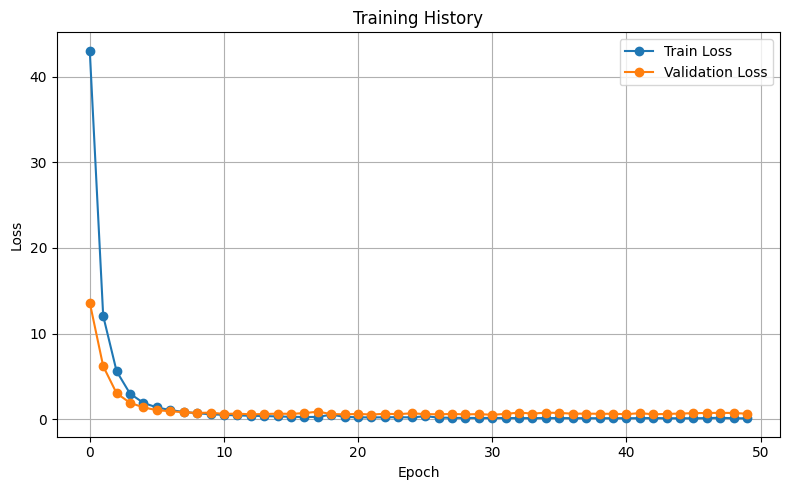

1/1 [==============================] - 0s 78ms/step



=== Entrenando: prostata_embeddings (ep=30, bs=64) ===
Epoch 1/30
49/49 [==============================] - 41s 640ms/step - loss: 68.9195 - accuracy: 0.8219 - val_loss_val: 18.7150 - val_val_accuracy: 0.9473
Epoch 2/30
49/49 [==============================] - 30s 606ms/step - loss: 20.0707 - accuracy: 0.9390 - val_loss_val: 12.1683 - val_val_accuracy: 0.9602
Epoch 3/30
49/49 [==============================] - 29s 604ms/step - loss: 12.4853 - accuracy: 0.9563 - val_loss_val: 7.2126 - val_val_accuracy: 0.9737
Epoch 4/30
49/49 [==============================] - 30s 606ms/step - loss: 7.2755 - accuracy: 0.9750 - val_loss_val: 4.1938 - val_val_accuracy: 0.9863
Epoch 5/30
49/49 [==============================] - 31s 638ms/step - loss: 4.4676 - accuracy: 0.9856 - val_loss_val: 2.7151 - val_val_accuracy: 0.9917
Epoch 6/30
49/49 [==============================] - 32s 658ms/step - loss: 3.0502 - accuracy: 0.9901 - val_loss_val: 1.9703 - val_val_accuracy: 0.9939
Epoch 7/30
49/49 [===============

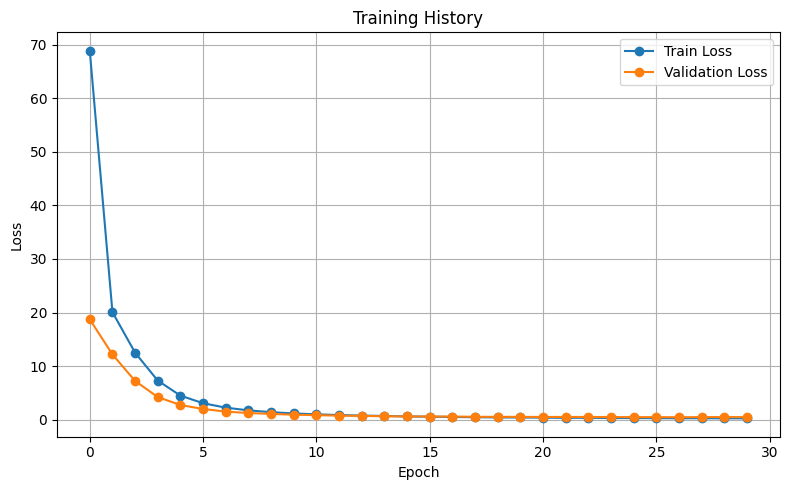

1/1 [==============================] - 0s 67ms/step



=== Entrenando: prostata_embeddings (ep=40, bs=64) ===
Epoch 1/40
49/49 [==============================] - 39s 624ms/step - loss: 65.1155 - accuracy: 0.8077 - val_loss_val: 18.4377 - val_val_accuracy: 0.9527
Epoch 2/40
49/49 [==============================] - 30s 611ms/step - loss: 20.0164 - accuracy: 0.9384 - val_loss_val: 12.4235 - val_val_accuracy: 0.9602
Epoch 3/40
49/49 [==============================] - 28s 573ms/step - loss: 13.1729 - accuracy: 0.9530 - val_loss_val: 7.8164 - val_val_accuracy: 0.9729
Epoch 4/40
49/49 [==============================] - 28s 574ms/step - loss: 7.9313 - accuracy: 0.9730 - val_loss_val: 4.6457 - val_val_accuracy: 0.9854
Epoch 5/40
49/49 [==============================] - 28s 577ms/step - loss: 4.7535 - accuracy: 0.9844 - val_loss_val: 2.9127 - val_val_accuracy: 0.9910
Epoch 6/40
49/49 [==============================] - 28s 576ms/step - loss: 3.1642 - accuracy: 0.9893 - val_loss_val: 2.0612 - val_val_accuracy: 0.9938
Epoch 7/40
49/49 [===============

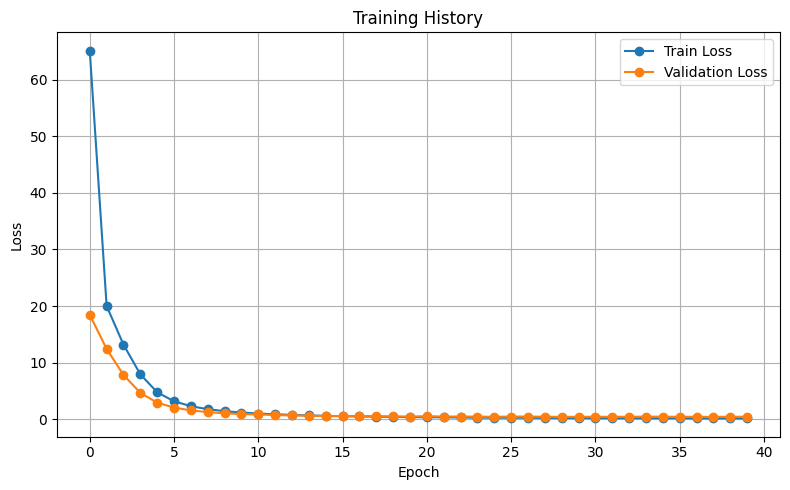

1/1 [==============================] - 0s 43ms/step



=== Entrenando: prostata_embeddings (ep=50, bs=64) ===
Epoch 1/50
49/49 [==============================] - 40s 640ms/step - loss: 64.9391 - accuracy: 0.8325 - val_loss_val: 18.3626 - val_val_accuracy: 0.9488
Epoch 2/50
49/49 [==============================] - 29s 600ms/step - loss: 19.6633 - accuracy: 0.9392 - val_loss_val: 12.1691 - val_val_accuracy: 0.9598
Epoch 3/50
49/49 [==============================] - 29s 600ms/step - loss: 12.2850 - accuracy: 0.9555 - val_loss_val: 7.1409 - val_val_accuracy: 0.9737
Epoch 4/50
49/49 [==============================] - 29s 587ms/step - loss: 7.0944 - accuracy: 0.9750 - val_loss_val: 4.1118 - val_val_accuracy: 0.9864
Epoch 5/50
49/49 [==============================] - 31s 641ms/step - loss: 4.4270 - accuracy: 0.9852 - val_loss_val: 2.6890 - val_val_accuracy: 0.9914
Epoch 6/50
49/49 [==============================] - 31s 635ms/step - loss: 3.0234 - accuracy: 0.9898 - val_loss_val: 1.9567 - val_val_accuracy: 0.9943
Epoch 7/50
49/49 [===============

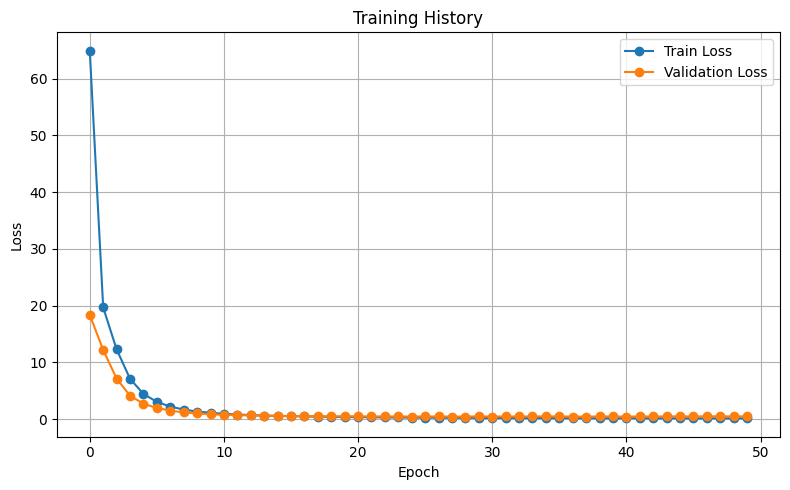

1/1 [==============================] - 0s 43ms/step



=== Entrenando: prostata_embeddings (ep=30, bs=128) ===
Epoch 1/30
25/25 [==============================] - 36s 1s/step - loss: 98.1730 - accuracy: 0.7220 - val_loss_val: 22.6811 - val_val_accuracy: 0.9413
Epoch 2/30
25/25 [==============================] - 25s 1s/step - loss: 25.4394 - accuracy: 0.9293 - val_loss_val: 17.6569 - val_val_accuracy: 0.9522
Epoch 3/30
25/25 [==============================] - 25s 999ms/step - loss: 20.2483 - accuracy: 0.9393 - val_loss_val: 14.0985 - val_val_accuracy: 0.9579
Epoch 4/30
25/25 [==============================] - 26s 1s/step - loss: 15.8892 - accuracy: 0.9461 - val_loss_val: 10.8380 - val_val_accuracy: 0.9620
Epoch 5/30
25/25 [==============================] - 23s 945ms/step - loss: 11.9410 - accuracy: 0.9564 - val_loss_val: 7.9693 - val_val_accuracy: 0.9721
Epoch 6/30
25/25 [==============================] - 24s 945ms/step - loss: 8.7113 - accuracy: 0.9697 - val_loss_val: 5.6854 - val_val_accuracy: 0.9806
Epoch 7/30
25/25 [===================

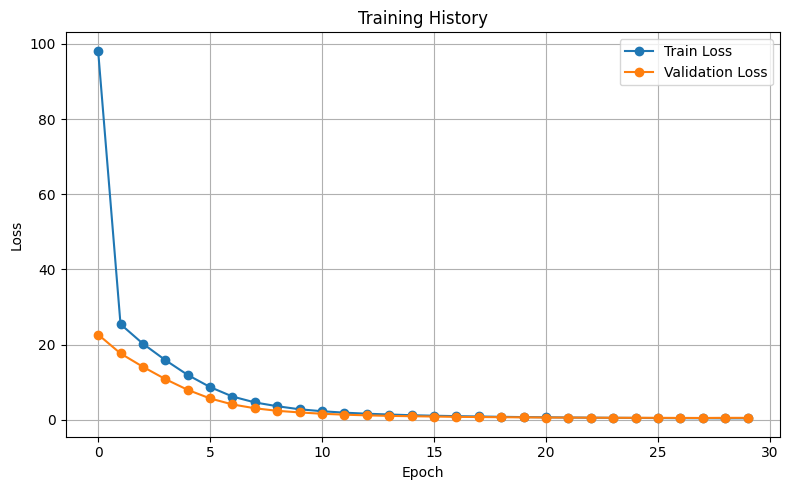

1/1 [==============================] - 0s 45ms/step



=== Entrenando: prostata_embeddings (ep=40, bs=128) ===
Epoch 1/40
25/25 [==============================] - 33s 983ms/step - loss: 84.5856 - accuracy: 0.8670 - val_loss_val: 22.6969 - val_val_accuracy: 0.9402
Epoch 2/40
25/25 [==============================] - 24s 957ms/step - loss: 24.8957 - accuracy: 0.9287 - val_loss_val: 17.2392 - val_val_accuracy: 0.9537
Epoch 3/40
25/25 [==============================] - 24s 983ms/step - loss: 19.8306 - accuracy: 0.9392 - val_loss_val: 13.7212 - val_val_accuracy: 0.9583
Epoch 4/40
25/25 [==============================] - 26s 1s/step - loss: 15.2714 - accuracy: 0.9464 - val_loss_val: 10.2770 - val_val_accuracy: 0.9630
Epoch 5/40
25/25 [==============================] - 25s 1s/step - loss: 10.9642 - accuracy: 0.9598 - val_loss_val: 7.2382 - val_val_accuracy: 0.9739
Epoch 6/40
25/25 [==============================] - 23s 924ms/step - loss: 7.6282 - accuracy: 0.9730 - val_loss_val: 5.0279 - val_val_accuracy: 0.9834
Epoch 7/40
25/25 [================

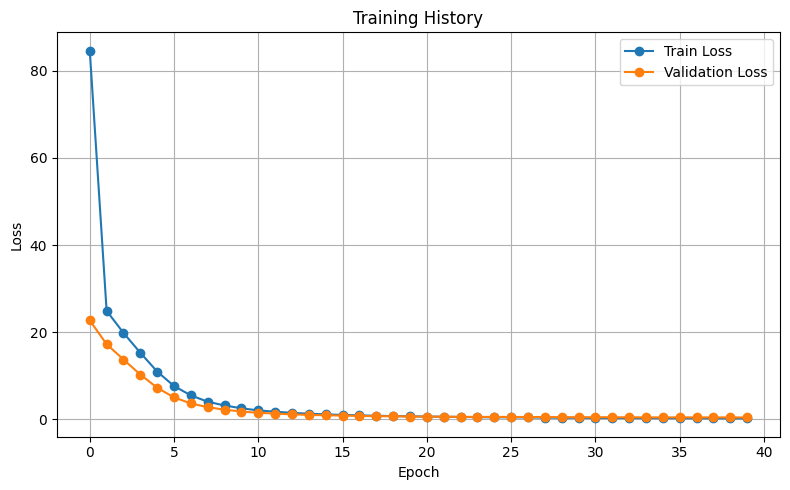

1/1 [==============================] - 0s 83ms/step



=== Entrenando: prostata_embeddings (ep=50, bs=128) ===
Epoch 1/50
25/25 [==============================] - 35s 1s/step - loss: 96.0240 - accuracy: 0.7181 - val_loss_val: 22.8436 - val_val_accuracy: 0.9424
Epoch 2/50
25/25 [==============================] - 25s 994ms/step - loss: 25.3172 - accuracy: 0.9282 - val_loss_val: 17.4707 - val_val_accuracy: 0.9501
Epoch 3/50
25/25 [==============================] - 25s 1s/step - loss: 19.6805 - accuracy: 0.9368 - val_loss_val: 13.8943 - val_val_accuracy: 0.9573
Epoch 4/50
25/25 [==============================] - 27s 1s/step - loss: 15.3684 - accuracy: 0.9451 - val_loss_val: 10.5786 - val_val_accuracy: 0.9617
Epoch 5/50
25/25 [==============================] - 26s 1s/step - loss: 11.4512 - accuracy: 0.9550 - val_loss_val: 7.6485 - val_val_accuracy: 0.9715
Epoch 6/50
25/25 [==============================] - 26s 1s/step - loss: 8.2142 - accuracy: 0.9701 - val_loss_val: 5.5072 - val_val_accuracy: 0.9811
Epoch 7/50
25/25 [=========================

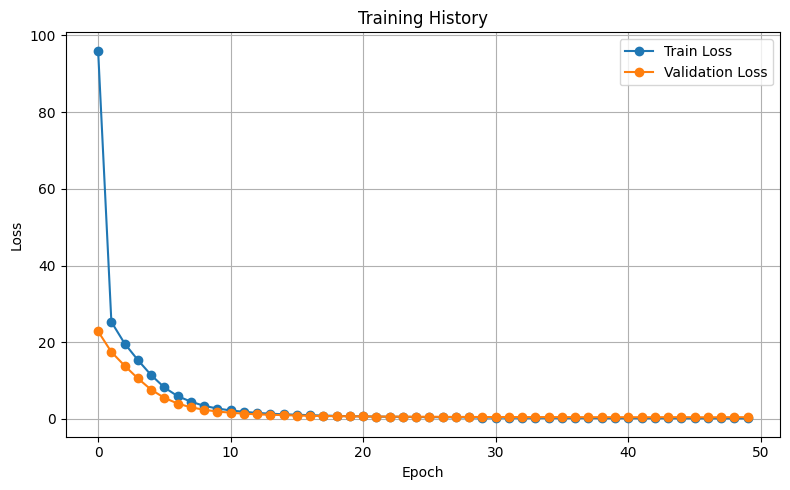

1/1 [==============================] - 0s 49ms/step


In [ ]:
# Recorre cada experimento definido en la lista de configuraciones
for exp in experiments:
    print(
        f"\n=== Entrenando: {exp['name']} (ep={exp['epochs']}, bs={exp['batch_size']}) ==="
    )

    # Construye el modelo BiLSTM+CRF, con o sin embeddings preentrenados según la configuración
    model = build_bilstm_crf_model(
        embedding_matrix=embedding_matrix if exp["use_embeddings"] else None,
    )

    # Entrena el modelo usando GPU (si está disponible)
    with tf.device("/device:GPU:0"):
        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_valid, y_valid),
            batch_size=exp["batch_size"],
            epochs=exp["epochs"],
            verbose=1,
        )

    # Genera predicciones sobre el conjunto de prueba
    y_pred = model.predict(X_test)

    # Evalúa el desempeño del modelo sobre los datos de prueba
    evaluate_predictions(y_pred, y_test, test_tokens, idx2tag)

    # Grafica la historia del entrenamiento (pérdida por época)
    plot_training_history(history.history)

    # Aplica el modelo a una muestra de texto procesada para visualizar predicciones
    y_pred_sample = model.predict(np.array([sample_processed]))
    visualize_entities_spacy_from_prediction(sample_text, y_pred_sample[0], idx2tag)

    # Guarda el modelo y su historial de entrenamiento
    save_model(
        model,
        history.history,
        base_name=exp["name"],
        epochs=exp["epochs"],
        batch_size=exp["batch_size"],
    )

In [ ]:
# Carga un modelo previamente entrenado junto con su historial
# y ejecuta evaluación, visualización de métricas y predicción sobre un ejemplo
def load_and_evaluate_experiment(
    base_name,
    epochs,
    batch_size,
):
    # Carga el modelo desde disco (incluye la capa CRF)
    model = load_model_from_drive(base_name, epochs, batch_size)

    # Carga el historial de entrenamiento correspondiente
    history = load_history_from_drive(base_name, epochs, batch_size)

    # Realiza predicciones sobre el conjunto de prueba
    y_pred = model.predict(X_test)

    # Evalúa las predicciones comparándolas con las etiquetas reales
    evaluate_predictions(y_pred, y_test, test_tokens, idx2tag)

    # Grafica la evolución de la pérdida durante el entrenamiento
    plot_training_history(history)

    # Realiza una predicción sobre un texto de ejemplo ya procesado
    y_pred_sample = model.predict(np.array([sample_processed]))

    # Visualiza las entidades detectadas sobre el texto original
    visualize_entities_spacy_from_prediction(sample_text, y_pred_sample[0], idx2tag)

✅ Modelo cargado desde: /content/drive/MyDrive/Personal/Universidad/8° Semestre/PLN/Taller 2/BiLSTM_CRF_Modelos/baseline_enterizacion_ep10_bs16
✅ Historial cargado desde: /content/drive/MyDrive/Personal/Universidad/8° Semestre/PLN/Taller 2/BiLSTM_CRF_Modelos/history_baseline_enterizacion_ep10_bs16.pkl
{'loss': [19.590023040771484, 4.818350315093994, 2.1160271167755127, 1.245542287826538, 0.868263304233551, 0.6576601266860962, 0.5813153982162476, 0.503156304359436, 0.41521382331848145, 0.3303075432777405], 'accuracy': [0.7876693606376648, 0.9399543404579163, 0.9715771079063416, 0.9839407801628113, 0.9880719780921936, 0.9914220571517944, 0.9920830726623535, 0.9933449625968933, 0.9938406944274902, 0.9949674010276794], 'val_loss_val': [5.866783142089844, 2.0524966716766357, 1.2022665739059448, 0.8943572640419006, 0.6445587277412415, 0.6131811738014221, 0.6755136251449585, 0.6518837809562683, 0.6574572324752808, 0.5286842584609985], 'val_val_accuracy': [0.9194831848144531, 0.969791233539581

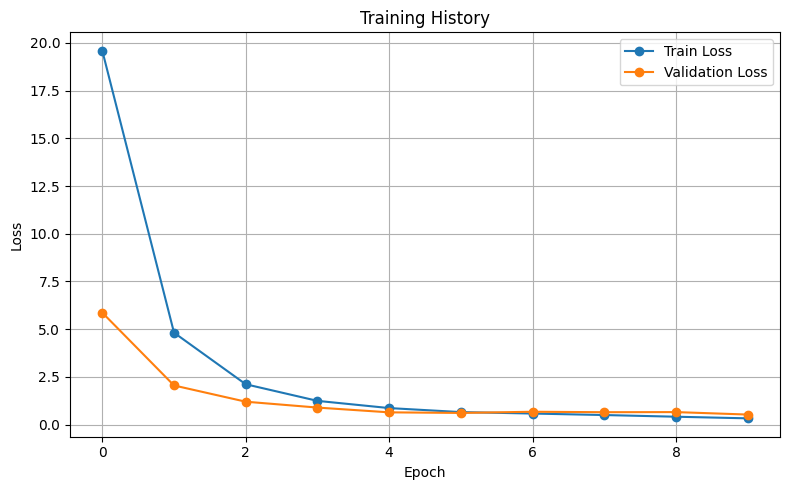

1/1 [==============================] - 0s 53ms/step


In [ ]:
# Carga y evalúa el modelo 'baseline_enterizacion' con 10 épocas y batch size de 16
load_and_evaluate_experiment("baseline_enterizacion", epochs=30, batch_size=32)

In [ ]:
# Ejecutar experimentos y guardar resultados
def run_all_experiments(configs):
    results = []
    for i, cfg in enumerate(configs):
        print(f"🔄 Running config {i+1}/{len(configs)}: {cfg}")
        result = load_and_evaluate_experiment(
            cfg["name"],
            epochs=cfg["epochs"],
            batch_size=cfg["batch_size"],
        )

def results_to_dataframe(results):
    df = pd.DataFrame(results)
    return df

🔄 Running config 1/18: {'name': 'prostata_enterizacion', 'use_embeddings': False, 'batch_size': 32, 'epochs': 30}
31/31 [==============================] - 4s 111ms/step
📊 Macro-F1 global: 0.9602

📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.99      0.97      0.98       206
      CANCER       0.94      0.96      0.95       362
     CIRUGIA       0.89      0.89      0.89        65
       DOSIS       0.92      0.88      0.90       189
        EDAD       0.96      0.99      0.98        80
       FECHA       1.00      0.98      0.99       400
     GLEASON       0.91      0.92      0.91       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       1.00      0.98      0.99        93
 TRATAMIENTO       0.97      0.98      0.97       246

   micro avg       0.96      0.96      0.96      1964
   macro avg       0.96      0.95      0.96      1964
weighted avg       0.96      0.96      0.96      1964



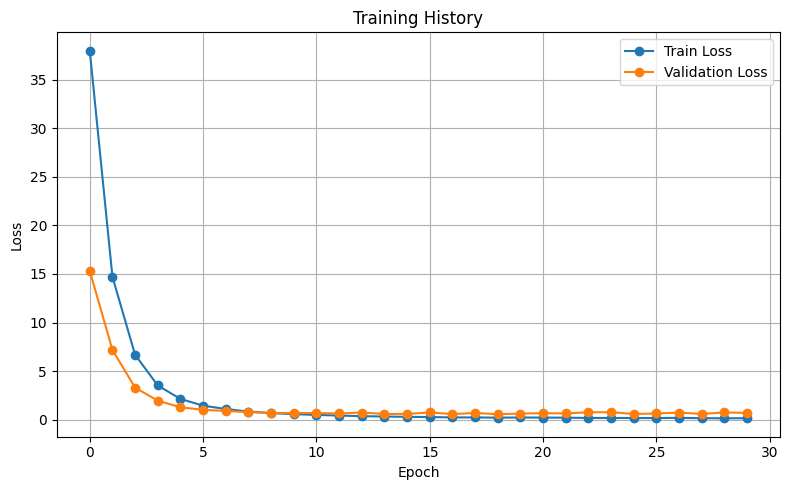

1/1 [==============================] - 0s 52ms/step


🔄 Running config 2/18: {'name': 'prostata_enterizacion', 'use_embeddings': False, 'batch_size': 32, 'epochs': 40}
31/31 [==============================] - 4s 112ms/step
📊 Macro-F1 global: 0.9584

📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.99      0.98      0.98       206
      CANCER       0.94      0.95      0.95       362
     CIRUGIA       0.89      0.91      0.90        65
       DOSIS       0.92      0.90      0.91       189
        EDAD       0.95      0.96      0.96        80
       FECHA       0.98      0.97      0.98       400
     GLEASON       0.91      0.92      0.92       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       0.99      0.97      0.98        93
 TRATAMIENTO       0.97      0.98      0.97       246

   micro avg       0.96      0.96      0.96      1964
   macro avg       0.95      0.95      0.95      1964
weighted avg       0.96      0.96      0.96      1964



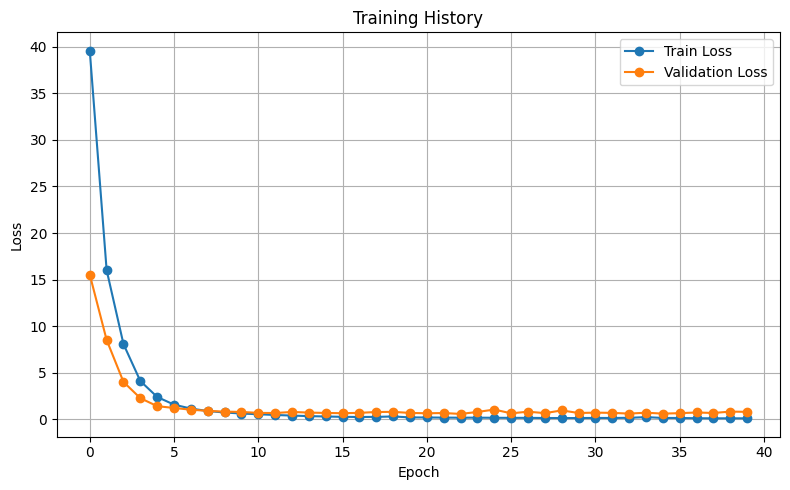

1/1 [==============================] - 0s 46ms/step


🔄 Running config 3/18: {'name': 'prostata_enterizacion', 'use_embeddings': False, 'batch_size': 32, 'epochs': 50}
31/31 [==============================] - 4s 123ms/step
📊 Macro-F1 global: 0.9635

📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.98      0.97      0.97       206
      CANCER       0.95      0.96      0.96       362
     CIRUGIA       0.90      0.88      0.89        65
       DOSIS       0.91      0.90      0.90       189
        EDAD       0.96      0.99      0.98        80
       FECHA       0.99      0.98      0.99       400
     GLEASON       0.92      0.94      0.93       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       1.00      0.98      0.99        93
 TRATAMIENTO       0.98      0.98      0.98       246

   micro avg       0.96      0.96      0.96      1964
   macro avg       0.96      0.96      0.96      1964
weighted avg       0.96      0.96      0.96      1964



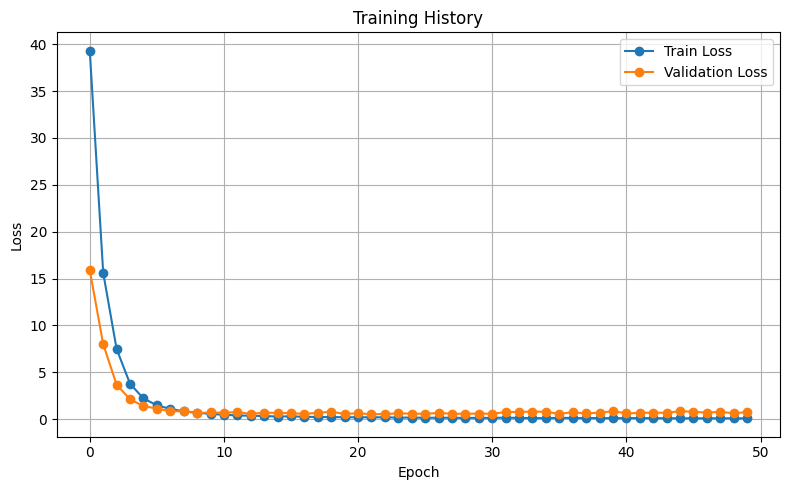

1/1 [==============================] - 0s 90ms/step


🔄 Running config 4/18: {'name': 'prostata_enterizacion', 'use_embeddings': False, 'batch_size': 64, 'epochs': 30}
31/31 [==============================] - 5s 162ms/step
📊 Macro-F1 global: 0.9595

📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.98      0.98      0.98       206
      CANCER       0.95      0.96      0.95       362
     CIRUGIA       0.91      0.91      0.91        65
       DOSIS       0.90      0.90      0.90       189
        EDAD       0.96      0.99      0.98        80
       FECHA       0.99      0.97      0.98       400
     GLEASON       0.90      0.91      0.90       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       1.00      0.98      0.99        93
 TRATAMIENTO       0.98      0.98      0.98       246

   micro avg       0.96      0.96      0.96      1964
   macro avg       0.96      0.96      0.96      1964
weighted avg       0.96      0.96      0.96      1964



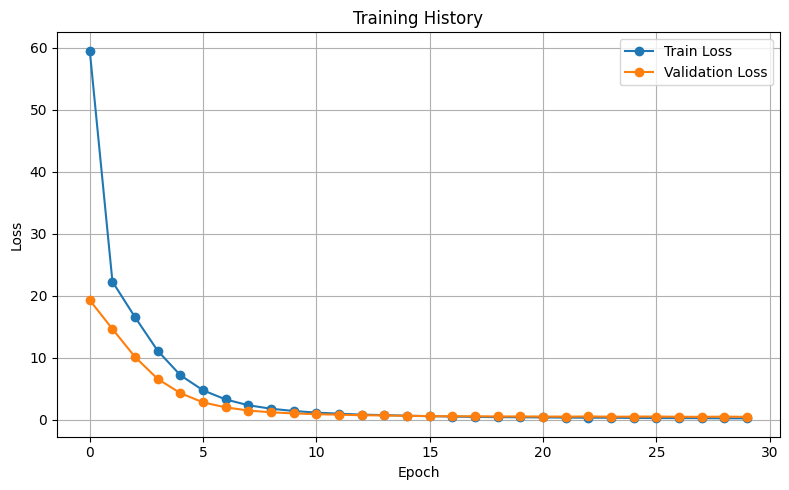

1/1 [==============================] - 0s 57ms/step


🔄 Running config 5/18: {'name': 'prostata_enterizacion', 'use_embeddings': False, 'batch_size': 64, 'epochs': 40}
31/31 [==============================] - 6s 173ms/step
📊 Macro-F1 global: 0.9636

📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.97      0.96      0.97       206
      CANCER       0.96      0.97      0.96       362
     CIRUGIA       0.91      0.91      0.91        65
       DOSIS       0.93      0.93      0.93       189
        EDAD       0.96      0.99      0.98        80
       FECHA       0.99      0.97      0.98       400
     GLEASON       0.92      0.93      0.93       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       0.99      0.97      0.98        93
 TRATAMIENTO       0.97      0.98      0.97       246

   micro avg       0.96      0.96      0.96      1964
   macro avg       0.96      0.96      0.96      1964
weighted avg       0.96      0.96      0.96      1964



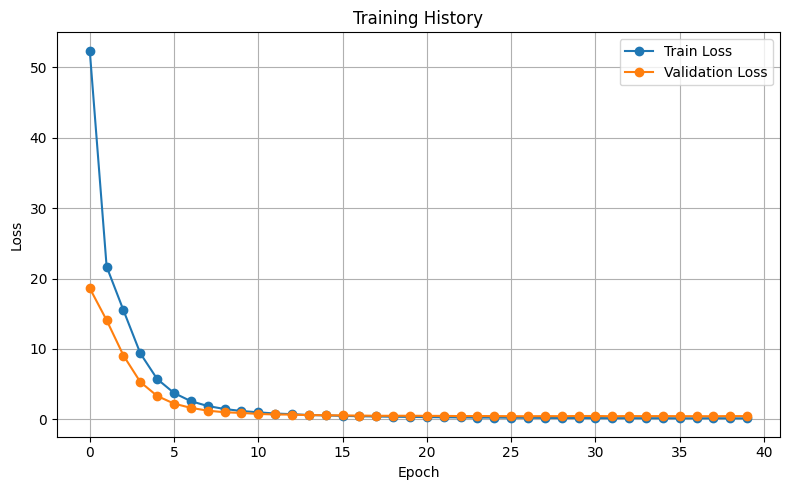

1/1 [==============================] - 0s 51ms/step


🔄 Running config 6/18: {'name': 'prostata_enterizacion', 'use_embeddings': False, 'batch_size': 64, 'epochs': 50}
31/31 [==============================] - 4s 120ms/step
📊 Macro-F1 global: 0.958

📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.98      0.97      0.97       206
      CANCER       0.95      0.96      0.95       362
     CIRUGIA       0.91      0.91      0.91        65
       DOSIS       0.87      0.89      0.88       189
        EDAD       0.96      0.99      0.98        80
       FECHA       0.99      0.97      0.98       400
     GLEASON       0.93      0.93      0.93       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       1.00      0.98      0.99        93
 TRATAMIENTO       0.96      0.97      0.97       246

   micro avg       0.96      0.96      0.96      1964
   macro avg       0.95      0.96      0.95      1964
weighted avg       0.96      0.96      0.96      1964



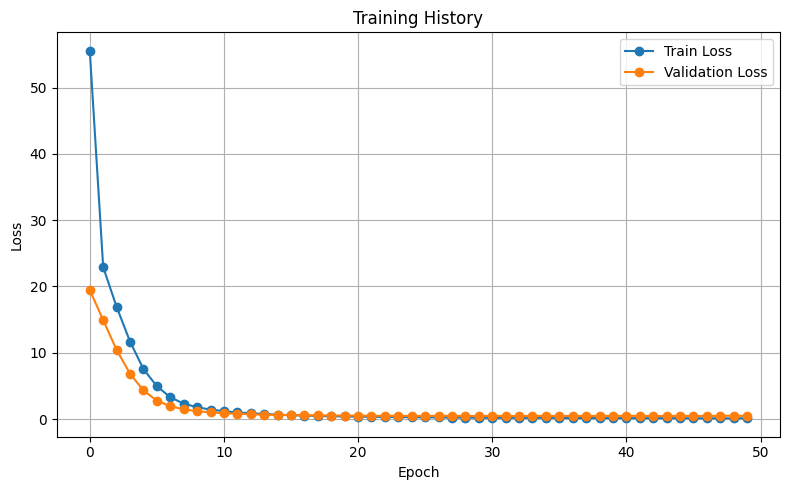

1/1 [==============================] - 0s 44ms/step


🔄 Running config 7/18: {'name': 'prostata_enterizacion', 'use_embeddings': False, 'batch_size': 128, 'epochs': 30}
31/31 [==============================] - 4s 114ms/step
📊 Macro-F1 global: 0.9465

📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.97      0.97      0.97       206
      CANCER       0.94      0.96      0.95       362
     CIRUGIA       0.89      0.89      0.89        65
       DOSIS       0.85      0.89      0.87       189
        EDAD       0.96      0.99      0.98        80
       FECHA       0.96      0.95      0.96       400
     GLEASON       0.88      0.89      0.88       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       1.00      0.98      0.99        93
 TRATAMIENTO       0.97      0.97      0.97       246

   micro avg       0.94      0.95      0.95      1964
   macro avg       0.94      0.95      0.94      1964
weighted avg       0.94      0.95      0.95      1964



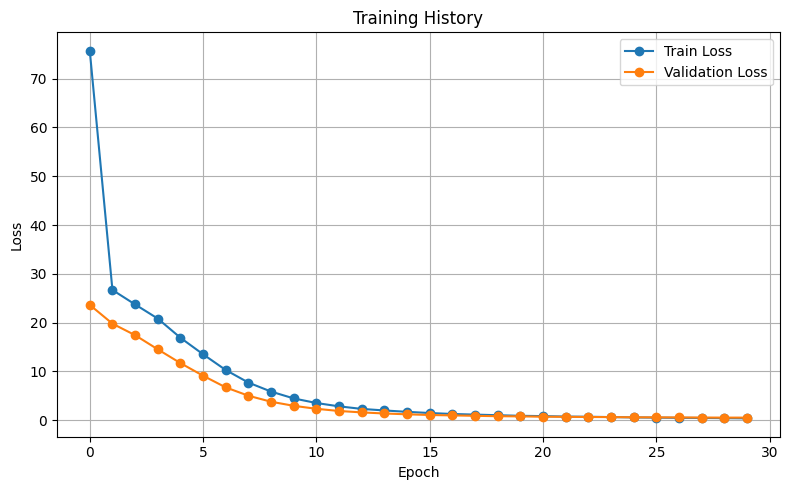

1/1 [==============================] - 0s 57ms/step


🔄 Running config 8/18: {'name': 'prostata_enterizacion', 'use_embeddings': False, 'batch_size': 128, 'epochs': 40}
31/31 [==============================] - 4s 119ms/step
📊 Macro-F1 global: 0.952

📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.96      0.95      0.95       206
      CANCER       0.93      0.96      0.95       362
     CIRUGIA       0.91      0.91      0.91        65
       DOSIS       0.89      0.90      0.89       189
        EDAD       0.96      0.99      0.98        80
       FECHA       0.98      0.97      0.97       400
     GLEASON       0.91      0.91      0.91       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       1.00      0.98      0.99        93
 TRATAMIENTO       0.95      0.97      0.96       246

   micro avg       0.95      0.96      0.95      1964
   macro avg       0.95      0.95      0.95      1964
weighted avg       0.95      0.96      0.95      1964



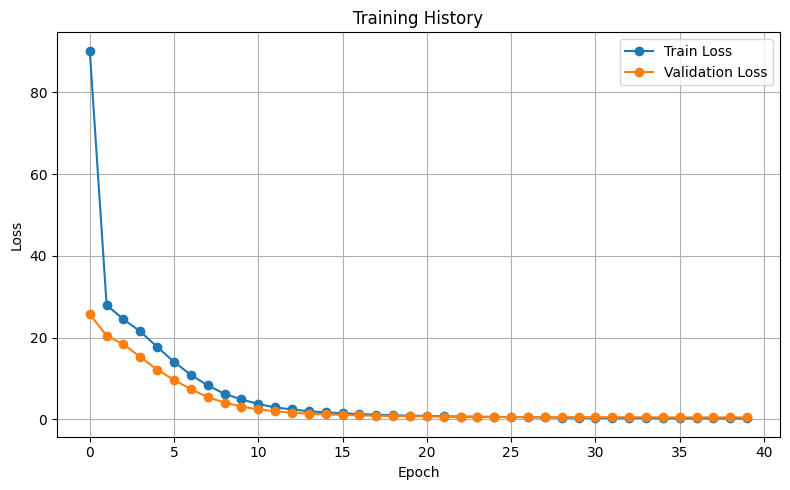

1/1 [==============================] - 0s 96ms/step


🔄 Running config 9/18: {'name': 'prostata_enterizacion', 'use_embeddings': False, 'batch_size': 128, 'epochs': 50}
31/31 [==============================] - 5s 140ms/step
📊 Macro-F1 global: 0.9527

📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.96      0.95      0.95       206
      CANCER       0.94      0.96      0.95       362
     CIRUGIA       0.89      0.89      0.89        65
       DOSIS       0.88      0.89      0.89       189
        EDAD       0.95      0.99      0.97        80
       FECHA       0.98      0.97      0.98       400
     GLEASON       0.89      0.91      0.90       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       0.97      0.96      0.96        93
 TRATAMIENTO       0.98      0.98      0.98       246

   micro avg       0.95      0.95      0.95      1964
   macro avg       0.94      0.95      0.95      1964
weighted avg       0.95      0.95      0.95      1964



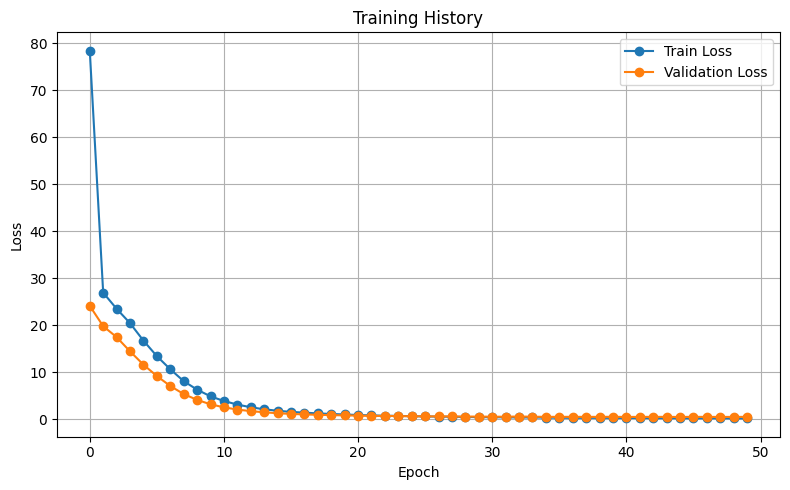

1/1 [==============================] - 0s 91ms/step


🔄 Running config 10/18: {'name': 'prostata_embeddings', 'use_embeddings': True, 'batch_size': 32, 'epochs': 30}
31/31 [==============================] - 6s 176ms/step
📊 Macro-F1 global: 0.9545

📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.96      0.98      0.97       206
      CANCER       0.95      0.95      0.95       362
     CIRUGIA       0.89      0.91      0.90        65
       DOSIS       0.88      0.92      0.90       189
        EDAD       0.96      0.96      0.96        80
       FECHA       0.99      0.98      0.99       400
     GLEASON       0.85      0.85      0.85       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       0.99      0.98      0.98        93
 TRATAMIENTO       0.97      0.98      0.97       246

   micro avg       0.95      0.96      0.95      1964
   macro avg       0.95      0.95      0.95      1964
weighted avg       0.95      0.96      0.95      1964



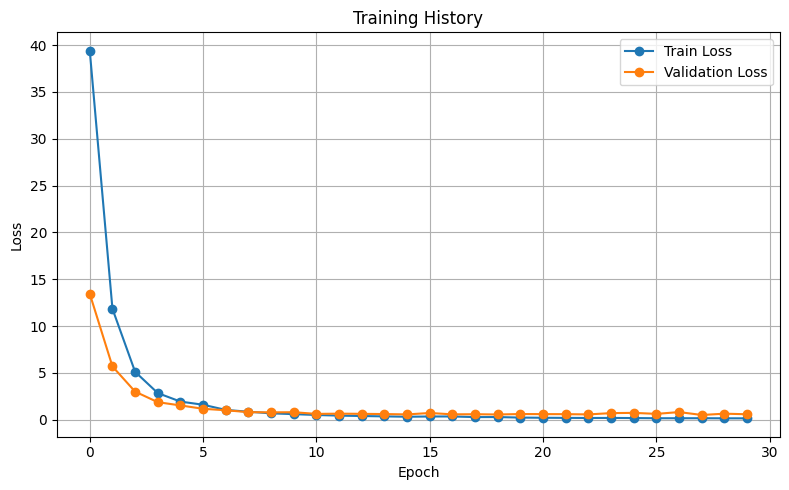

1/1 [==============================] - 0s 56ms/step


🔄 Running config 11/18: {'name': 'prostata_embeddings', 'use_embeddings': True, 'batch_size': 32, 'epochs': 40}
31/31 [==============================] - 4s 112ms/step
📊 Macro-F1 global: 0.9544

📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.98      0.98      0.98       206
      CANCER       0.94      0.94      0.94       362
     CIRUGIA       0.91      0.91      0.91        65
       DOSIS       0.91      0.92      0.91       189
        EDAD       0.96      0.95      0.96        80
       FECHA       0.99      0.98      0.99       400
     GLEASON       0.85      0.86      0.85       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       0.97      0.98      0.97        93
 TRATAMIENTO       0.97      0.98      0.97       246

   micro avg       0.95      0.95      0.95      1964
   macro avg       0.95      0.95      0.95      1964
weighted avg       0.95      0.95      0.95      1964



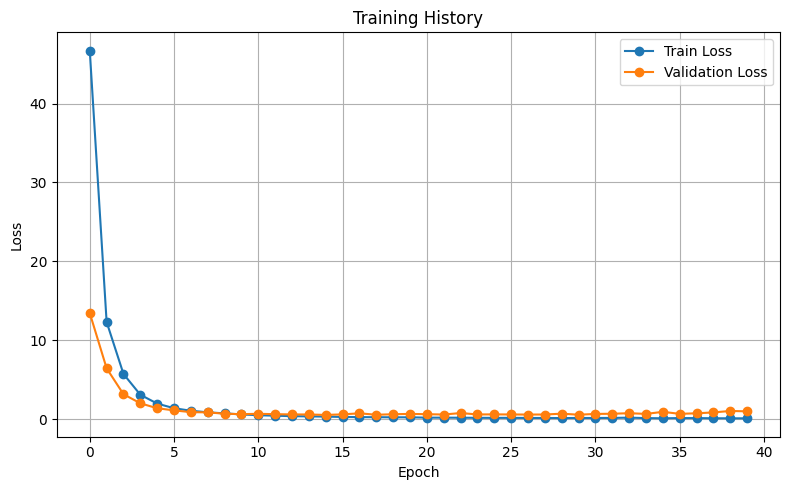

1/1 [==============================] - 0s 50ms/step


🔄 Running config 12/18: {'name': 'prostata_embeddings', 'use_embeddings': True, 'batch_size': 32, 'epochs': 50}
31/31 [==============================] - 4s 119ms/step
📊 Macro-F1 global: 0.9616

📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.97      0.98      0.97       206
      CANCER       0.96      0.96      0.96       362
     CIRUGIA       0.89      0.91      0.90        65
       DOSIS       0.91      0.92      0.91       189
        EDAD       0.96      0.99      0.98        80
       FECHA       0.99      0.98      0.99       400
     GLEASON       0.91      0.90      0.90       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       1.00      0.98      0.99        93
 TRATAMIENTO       0.98      0.98      0.98       246

   micro avg       0.96      0.96      0.96      1964
   macro avg       0.96      0.96      0.96      1964
weighted avg       0.96      0.96      0.96      1964



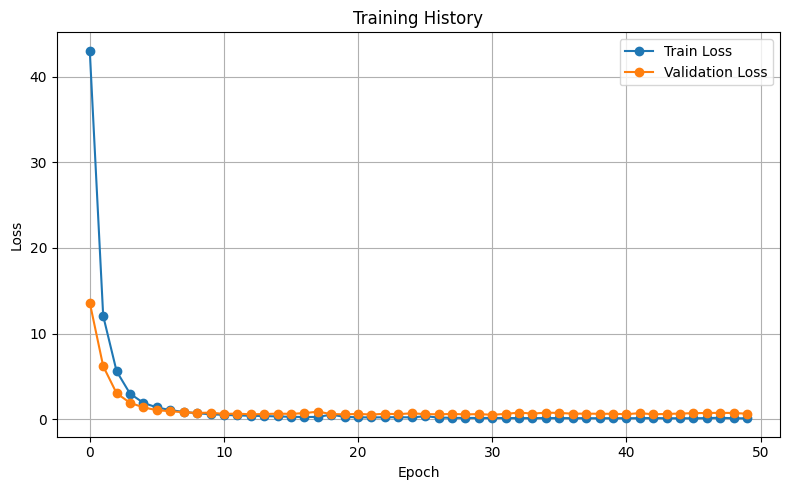

1/1 [==============================] - 0s 81ms/step


🔄 Running config 13/18: {'name': 'prostata_embeddings', 'use_embeddings': True, 'batch_size': 64, 'epochs': 30}
31/31 [==============================] - 5s 150ms/step
📊 Macro-F1 global: 0.9506

📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.94      0.98      0.96       206
      CANCER       0.92      0.95      0.93       362
     CIRUGIA       0.89      0.91      0.90        65
       DOSIS       0.88      0.90      0.89       189
        EDAD       0.96      0.99      0.98        80
       FECHA       1.00      0.98      0.99       400
     GLEASON       0.87      0.87      0.87       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       0.98      0.97      0.97        93
 TRATAMIENTO       0.97      0.98      0.97       246

   micro avg       0.95      0.96      0.95      1964
   macro avg       0.94      0.95      0.95      1964
weighted avg       0.95      0.96      0.95      1964



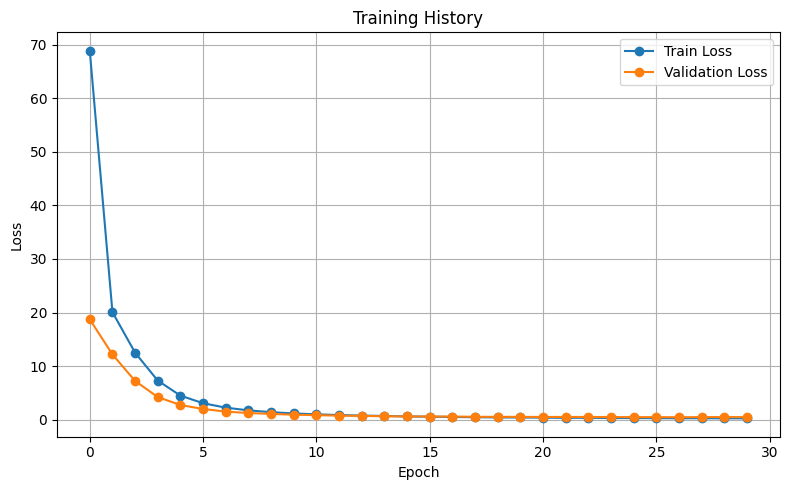

1/1 [==============================] - 0s 107ms/step


🔄 Running config 14/18: {'name': 'prostata_embeddings', 'use_embeddings': True, 'batch_size': 64, 'epochs': 40}
31/31 [==============================] - 6s 175ms/step
📊 Macro-F1 global: 0.9526

📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.95      0.97      0.96       206
      CANCER       0.94      0.95      0.95       362
     CIRUGIA       0.89      0.91      0.90        65
       DOSIS       0.91      0.90      0.90       189
        EDAD       0.96      0.99      0.98        80
       FECHA       0.99      0.97      0.98       400
     GLEASON       0.84      0.84      0.84       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       0.99      0.97      0.98        93
 TRATAMIENTO       0.98      0.98      0.98       246

   micro avg       0.95      0.95      0.95      1964
   macro avg       0.95      0.95      0.95      1964
weighted avg       0.95      0.95      0.95      1964



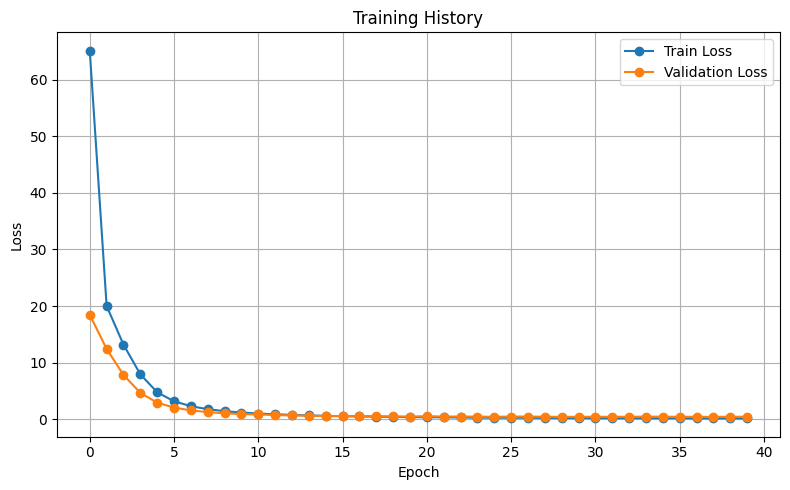

1/1 [==============================] - 0s 50ms/step


🔄 Running config 15/18: {'name': 'prostata_embeddings', 'use_embeddings': True, 'batch_size': 64, 'epochs': 50}
31/31 [==============================] - 4s 118ms/step
📊 Macro-F1 global: 0.9519

📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.96      0.98      0.97       206
      CANCER       0.94      0.96      0.95       362
     CIRUGIA       0.86      0.86      0.86        65
       DOSIS       0.91      0.90      0.90       189
        EDAD       0.95      0.97      0.96        80
       FECHA       0.99      0.97      0.98       400
     GLEASON       0.84      0.85      0.84       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       1.00      0.98      0.99        93
 TRATAMIENTO       0.98      0.98      0.98       246

   micro avg       0.95      0.95      0.95      1964
   macro avg       0.94      0.94      0.94      1964
weighted avg       0.95      0.95      0.95      1964



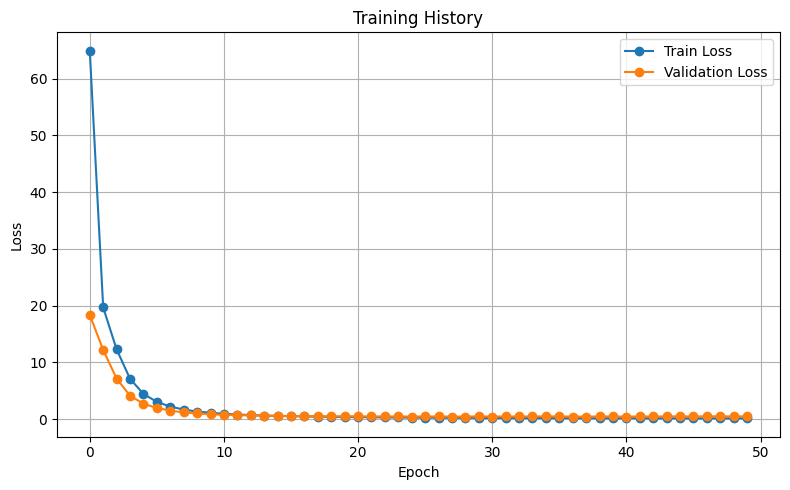

1/1 [==============================] - 0s 48ms/step


🔄 Running config 16/18: {'name': 'prostata_embeddings', 'use_embeddings': True, 'batch_size': 128, 'epochs': 30}
31/31 [==============================] - 4s 116ms/step
📊 Macro-F1 global: 0.9475

📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.93      0.98      0.95       206
      CANCER       0.94      0.96      0.95       362
     CIRUGIA       0.88      0.89      0.89        65
       DOSIS       0.86      0.88      0.87       189
        EDAD       0.96      0.99      0.98        80
       FECHA       0.99      0.97      0.98       400
     GLEASON       0.85      0.86      0.85       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       1.00      0.97      0.98        93
 TRATAMIENTO       0.96      0.97      0.97       246

   micro avg       0.94      0.95      0.95      1964
   macro avg       0.94      0.95      0.94      1964
weighted avg       0.94      0.95      0.95      1964



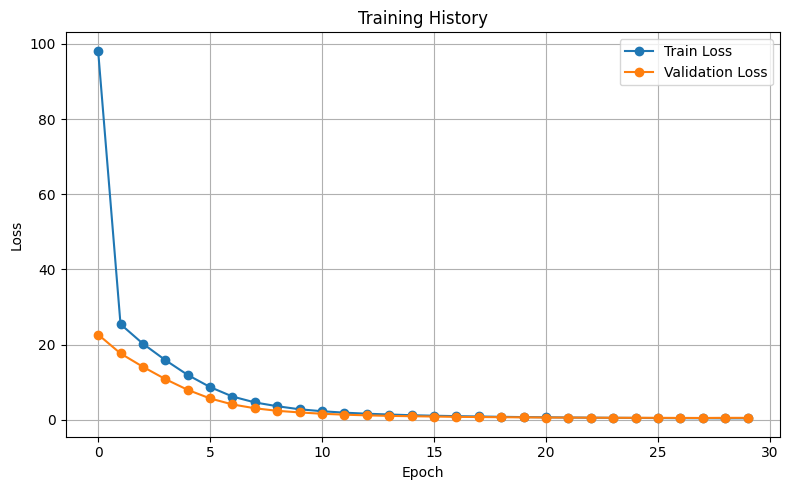

1/1 [==============================] - 0s 56ms/step


🔄 Running config 17/18: {'name': 'prostata_embeddings', 'use_embeddings': True, 'batch_size': 128, 'epochs': 40}
31/31 [==============================] - 5s 138ms/step
📊 Macro-F1 global: 0.9468

📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.93      0.97      0.95       206
      CANCER       0.93      0.95      0.94       362
     CIRUGIA       0.89      0.91      0.90        65
       DOSIS       0.88      0.89      0.88       189
        EDAD       0.96      0.99      0.98        80
       FECHA       0.99      0.98      0.98       400
     GLEASON       0.84      0.83      0.83       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       1.00      0.97      0.98        93
 TRATAMIENTO       0.97      0.98      0.97       246

   micro avg       0.94      0.95      0.95      1964
   macro avg       0.94      0.95      0.94      1964
weighted avg       0.94      0.95      0.95      1964



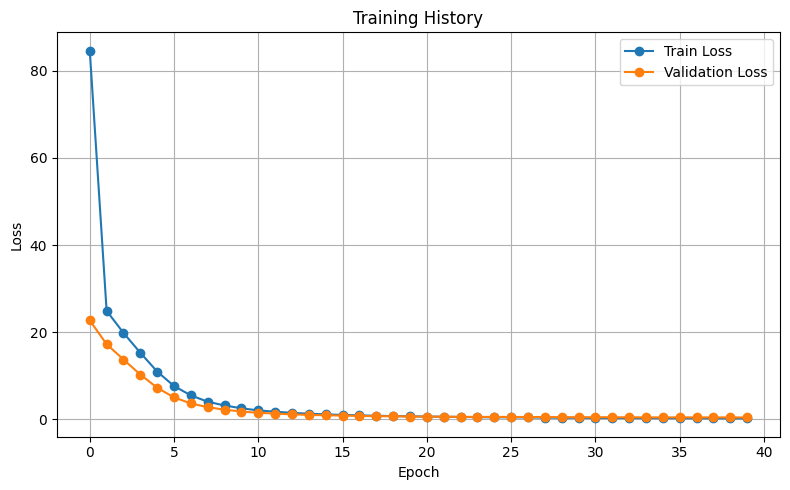

1/1 [==============================] - 0s 98ms/step


🔄 Running config 18/18: {'name': 'prostata_embeddings', 'use_embeddings': True, 'batch_size': 128, 'epochs': 50}
31/31 [==============================] - 5s 150ms/step
📊 Macro-F1 global: 0.9527

📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.96      0.98      0.97       206
      CANCER       0.95      0.97      0.96       362
     CIRUGIA       0.88      0.91      0.89        65
       DOSIS       0.90      0.90      0.90       189
        EDAD       0.96      0.99      0.98        80
       FECHA       0.99      0.97      0.98       400
     GLEASON       0.84      0.83      0.83       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       0.99      0.97      0.98        93
 TRATAMIENTO       0.98      0.98      0.98       246

   micro avg       0.95      0.95      0.95      1964
   macro avg       0.94      0.95      0.95      1964
weighted avg       0.95      0.95      0.95      1964



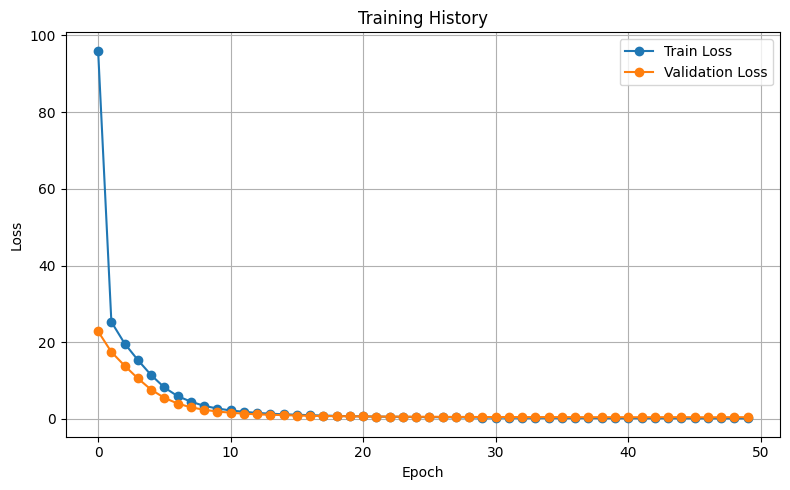

1/1 [==============================] - 0s 103ms/step


In [ ]:
run_all_experiments(experiments)

# # Crear tabla
# df_results = results_to_dataframe(results)

# print(df_results)

31/31 [==============================] - 3s 95ms/step
Macro-F1 global: 0.9616
Macro-Precision global: 0.9613
Macro-Recall global: 0.9618

Reporte completo:


📄 Reporte completo:

              precision    recall  f1-score   support

 BIOMARCADOR       0.97      0.98      0.97       206
      CANCER       0.96      0.96      0.96       362
     CIRUGIA       0.89      0.91      0.90        65
       DOSIS       0.91      0.92      0.91       189
        EDAD       0.96      0.99      0.98        80
       FECHA       0.99      0.98      0.99       400
     GLEASON       0.91      0.90      0.90       159
 MEDICAMENTO       0.99      0.99      0.99       164
         TNM       1.00      0.98      0.99        93
 TRATAMIENTO       0.98      0.98      0.98       246

   micro avg       0.96      0.96      0.96      1964
   macro avg       0.96      0.96      0.96      1964
weighted avg       0.96      0.96      0.96      1964



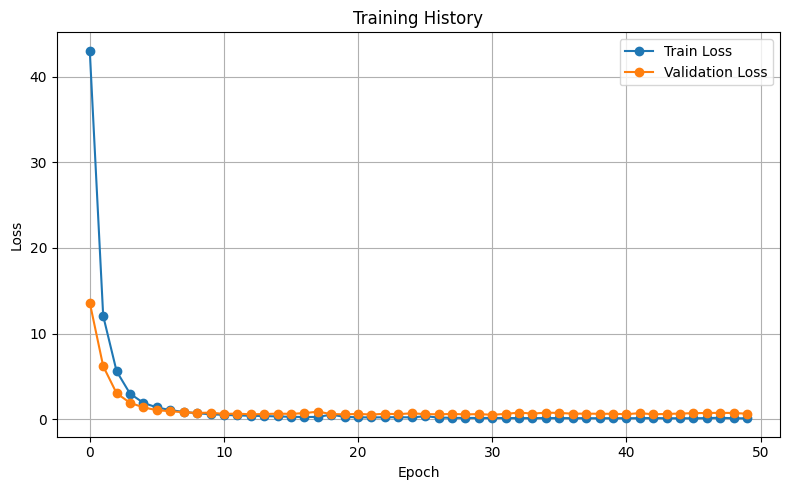

1/1 [==============================] - 0s 43ms/step


In [ ]:
load_and_evaluate_experiment("prostata_embeddings", epochs=50, batch_size=32)